Dataset loaded: (150, 4)


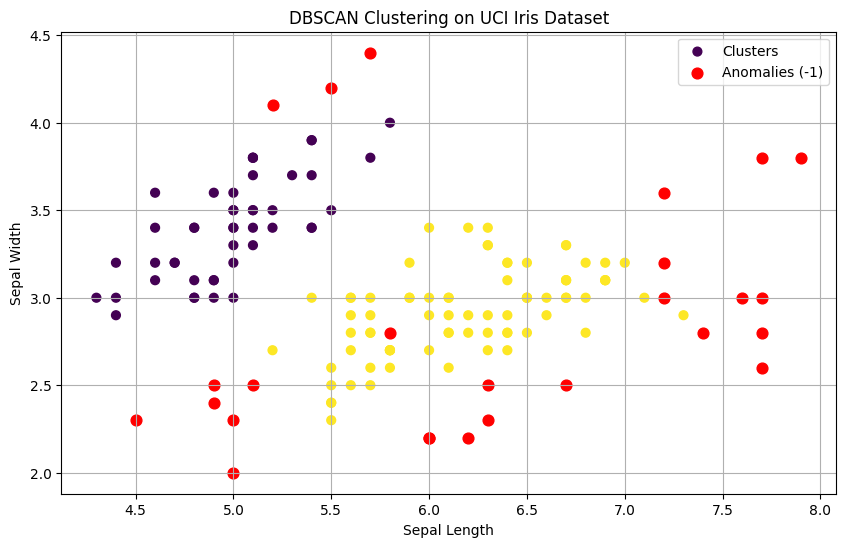


DBSCAN Cluster Counts:
cluster
 1    78
 0    46
-1    26
Name: count, dtype: int64

Meaning:
 -1 = Anomalies (points DBSCAN could not cluster)
  0,1,2... = Natural clusters in the data


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# ---------------------------------------------------------
# 1. LOAD IRIS DATASET (Always works)
# ---------------------------------------------------------
iris = load_iris()
X = iris.data
df = pd.DataFrame(X, columns=iris.feature_names)

print("Dataset loaded:", df.shape)

# ---------------------------------------------------------
# 2. SCALE FEATURES
# ---------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ---------------------------------------------------------
# 3. RUN DBSCAN
# ---------------------------------------------------------
db = DBSCAN(eps=0.6, min_samples=5)
labels = db.fit_predict(X_scaled)

df['cluster'] = labels

# ---------------------------------------------------------
# 4. VISUALIZE CLUSTERS
# ---------------------------------------------------------
plt.figure(figsize=(10,6))

normal = df[df['cluster'] != -1]
anomalies = df[df['cluster'] == -1]

plt.scatter(normal['sepal length (cm)'], normal['sepal width (cm)'],
            c=normal['cluster'], cmap='viridis', s=40, label="Clusters")

plt.scatter(anomalies['sepal length (cm)'], anomalies['sepal width (cm)'],
            color='red', s=60, label="Anomalies (-1)")

plt.title("DBSCAN Clustering on UCI Iris Dataset")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 5. PRINT CLUSTER SUMMARY
# ---------------------------------------------------------
print("\nDBSCAN Cluster Counts:")
print(df['cluster'].value_counts())

print("\nMeaning:")
print(" -1 = Anomalies (points DBSCAN could not cluster)")
print("  0,1,2... = Natural clusters in the data")